# Anomaly Injection Validation Analysis

This notebook validates whether injected anomalies are actually visible in the generated AIS databases under the anomaly folders.

It provides evidence-focused checks for:
- Disappearance: highly regular reporting before a hard stop.
- Speeding: abrupt speed spikes in otherwise lower-speed tracks.
- Loitering: movement constrained near a center point with low speeds.

In [1]:
from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [2]:
def find_anomaly_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    # Support both spellings to be robust to folder naming.
    for base in [cwd, *cwd.parents]:
        candidates.append(base / "actint" / "data" / "db" / "anomalies")
        candidates.append(base / "actint" / "data" / "db" / "anomolies")
        candidates.append(base / "data" / "db" / "anomalies")
        candidates.append(base / "data" / "db" / "anomolies")

    for path in candidates:
        if path.exists() and path.is_dir():
            return path

    raise FileNotFoundError("Could not find anomaly database root folder.")


def latest_run_dir(scenario_root: Path) -> Path:
    run_dirs = sorted([p for p in scenario_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under: {scenario_root}")
    return run_dirs[-1]


def load_manifest(run_dir: Path) -> dict:
    manifest_path = run_dir / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest: {manifest_path}")
    return json.loads(manifest_path.read_text(encoding="utf-8"))


def db_path_from_run(run_dir: Path) -> Path:
    db_files = sorted(run_dir.glob("*.db"))
    if not db_files:
        raise FileNotFoundError(f"No .db found in {run_dir}")
    return db_files[0]


anomaly_root = find_anomaly_root()
scenario_names = ["disappearance", "speeding", "loitering"]

runs = {}
for scenario in scenario_names:
    run_dir = latest_run_dir(anomaly_root / scenario)
    runs[scenario] = {
        "run_dir": run_dir,
        "db_path": db_path_from_run(run_dir),
        "manifest": load_manifest(run_dir),
    }

pd.DataFrame(
    {
        s: {
            "run_dir": str(v["run_dir"]),
            "db_path": str(v["db_path"]),
            "anomaly_count": v["manifest"].get("anomaly_count"),
            "created_at": v["manifest"].get("created_at"),
        }
        for s, v in runs.items()
    }
).T

,run_dir,db_path,anomaly_count,created_at
disappearance,/home/daxtonb/Actint/actint-backend/data/db/an...,/home/daxtonb/Actint/actint-backend/data/db/an...,5,2026-05-05T16:50:44.250472Z
speeding,/home/daxtonb/Actint/actint-backend/data/db/an...,/home/daxtonb/Actint/actint-backend/data/db/an...,5,2026-05-05T16:50:44.250472Z
loitering,/home/daxtonb/Actint/actint-backend/data/db/an...,/home/daxtonb/Actint/actint-backend/data/db/an...,5,2026-05-05T16:50:44.049312Z


In [3]:
def load_positions(db_path: Path, mmsis: list[int]) -> pd.DataFrame:
    placeholders = ",".join(["?"] * len(mmsis))
    sql = f"""
        SELECT
            mmsi,
            base_datetime,
            lat,
            lon,
            sog,
            cog,
            vessel_name
        FROM ais_positions
        WHERE mmsi IN ({placeholders})
        ORDER BY mmsi, base_datetime
    """
    conn = sqlite3.connect(str(db_path))
    try:
        df = pd.read_sql_query(sql, conn, params=mmsis)
    finally:
        conn.close()

    df["base_datetime"] = pd.to_datetime(df["base_datetime"], utc=False, errors="coerce")
    return df


def to_nm_distance(lat1, lon1, lat2, lon2):
    # Haversine distance in nautical miles.
    r_earth_nm = 3440.065
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r_earth_nm * c

In [4]:
def sample_normal_mmsis(db_path: Path, excluded_mmsis: list[int], sample_size: int = 12, min_points: int = 150, seed: int = 7) -> list[int]:
    excluded = set(int(x) for x in excluded_mmsis)
    conn = sqlite3.connect(str(db_path))
    try:
        q = """
            SELECT mmsi, COUNT(*) AS n
            FROM ais_positions
            GROUP BY mmsi
            HAVING COUNT(*) >= ?
        """
        candidates = pd.read_sql_query(q, conn, params=[min_points])
    finally:
        conn.close()

    if candidates.empty:
        return []

    candidates["mmsi"] = candidates["mmsi"].astype(int)
    candidates = candidates[~candidates["mmsi"].isin(excluded)].copy()
    if candidates.empty:
        return []

    n = min(sample_size, len(candidates))
    return candidates.sample(n=n, random_state=seed)["mmsi"].tolist()

In [5]:
dis_manifest = runs["disappearance"]["manifest"]
dis_anoms = pd.DataFrame(dis_manifest.get("anomalies", []))
dis_mmsis = dis_anoms["mmsi"].astype(int).tolist()

print(dis_anoms)

            anomaly_id       mmsi         vessel_name  source_mmsi  source_vessel_name           start_time             end_time  point_count  interval_seconds  mean_sog_knots
0  DISAPPEAR-338951000  338951000  USS LAKE CHAMPLAIN    338951000  USS LAKE CHAMPLAIN  2023-01-01T00:00:01  2023-01-01T06:26:51          391         59.514611          11.996
1  DISAPPEAR-369970719  369970719       USS ARLINGTON    369970719       USS ARLINGTON  2023-01-01T00:00:01  2023-01-01T06:35:36          397         59.938101          12.024
2  DISAPPEAR-369970709  369970709     USS LITTLE ROCK    369970709     USS LITTLE ROCK  2023-01-01T00:00:01  2023-01-01T06:54:21          417         59.760324          11.991
3  DISAPPEAR-369970707  369970707       USS MILWAUKEE    369970707       USS MILWAUKEE  2023-01-01T00:00:01  2023-01-01T06:35:51          402         59.227974          12.012
4  DISAPPEAR-368869000  368869000          USS O'KANE    368869000          USS O'KANE  2023-01-01T00:00:01  2023-01-01T

## Disappearance Validation

Goal: show injected ships had a very regular ping cadence and then stopped reporting, leaving a long expected gap.

In [6]:
dis_manifest = runs["disappearance"]["manifest"]
dis_anoms = pd.DataFrame(dis_manifest.get("anomalies", []))
dis_mmsis = dis_anoms["mmsi"].astype(int).tolist()

dis_positions = load_positions(runs["disappearance"]["db_path"], dis_mmsis)
dis_positions = dis_positions.sort_values(["mmsi", "base_datetime"]).copy()
dis_positions["dt_seconds"] = dis_positions.groupby("mmsi")["base_datetime"].diff().dt.total_seconds()

regularity = (
    dis_positions.dropna(subset=["dt_seconds"])
    .groupby("mmsi")
    .agg(
        median_interval_s=("dt_seconds", "median"),
        std_interval_s=("dt_seconds", "std"),
        cv_interval=("dt_seconds", lambda s: (s.std() / s.mean()) if s.mean() else np.nan),
    )
    .reset_index()
)

# dis_check = dis_anoms[["mmsi", "vessel_name", "expected_gap_seconds", "interval_seconds"]].merge(
dis_check = dis_anoms[["mmsi", "vessel_name", "interval_seconds"]].merge(
    regularity, on="mmsi", how="left"
)
# dis_check["expected_gap_hours"] = dis_check["expected_gap_seconds"] / 3600.0
dis_check["interval_hours"] = dis_check["interval_seconds"] / 3600.0
dis_check = dis_check.sort_values("cv_interval")

dis_check.head(10)

,mmsi,vessel_name,interval_seconds,median_interval_s,std_interval_s,cv_interval,interval_hours
0,338951000,USS LAKE CHAMPLAIN,59.514611,58.887825,9.367262,0.157394,0.016532
4,368869000,USS O'KANE,59.909868,60.283147,9.928645,0.165726,0.016642
3,369970707,USS MILWAUKEE,59.227974,59.237101,10.076279,0.170127,0.016452
1,369970719,USS ARLINGTON,59.938101,59.608626,10.288922,0.171659,0.016649
2,369970709,USS LITTLE ROCK,59.760324,60.175802,10.453263,0.174920,0.016600


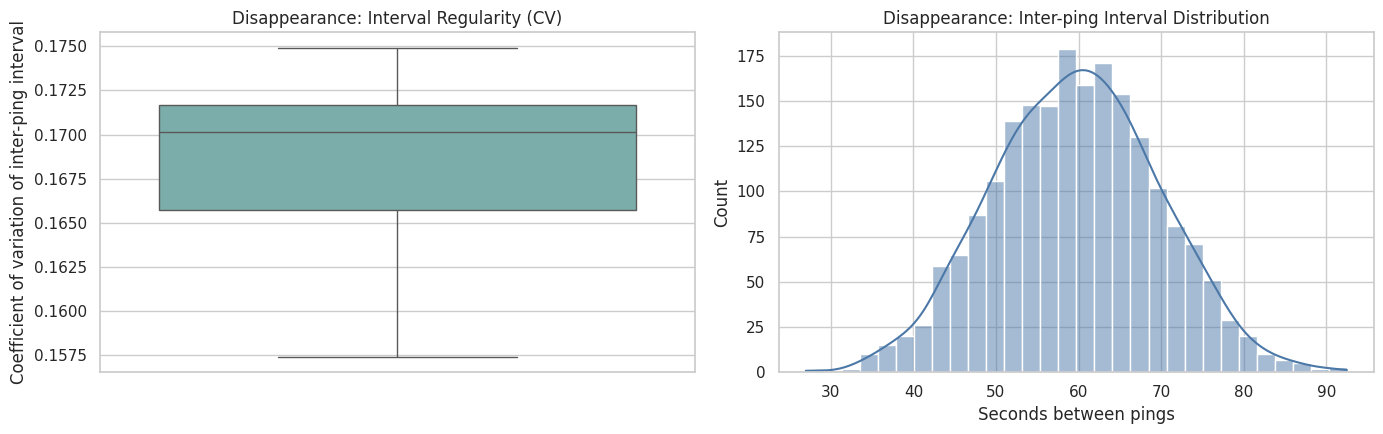

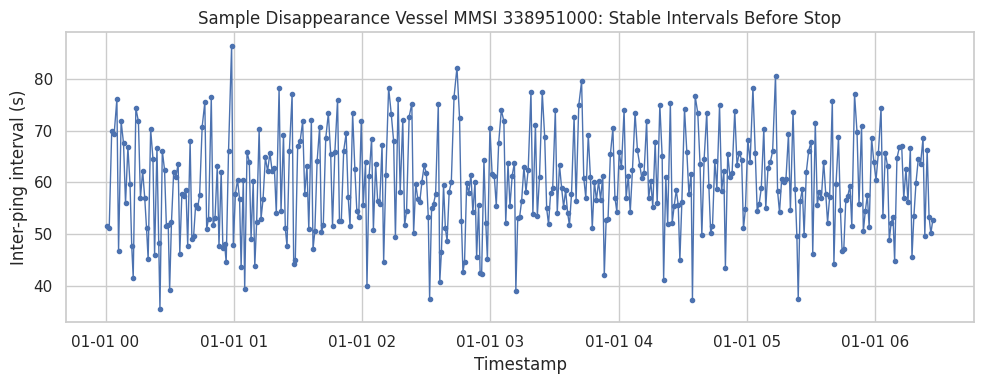

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=dis_check, y="cv_interval", ax=axes[0], color="#72b7b2")
axes[0].set_title("Disappearance: Interval Regularity (CV)")
axes[0].set_ylabel("Coefficient of variation of inter-ping interval")

sns.histplot(dis_positions["dt_seconds"].dropna(), bins=30, kde=True, ax=axes[1], color="#4c78a8")
axes[1].set_title("Disappearance: Inter-ping Interval Distribution")
axes[1].set_xlabel("Seconds between pings")

plt.tight_layout()
plt.show()

sample_dis_mmsi = int(dis_check.iloc[0]["mmsi"])
sample = dis_positions[dis_positions["mmsi"] == sample_dis_mmsi].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample["base_datetime"], sample["dt_seconds"], marker=".", linewidth=1)
ax.set_title(f"Sample Disappearance Vessel MMSI {sample_dis_mmsi}: Stable Intervals Before Stop")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Inter-ping interval (s)")
plt.tight_layout()
plt.show()

### Injected vs Normal (Disappearance)

Compare injected disappearance ships against non-injected ships from the same database.

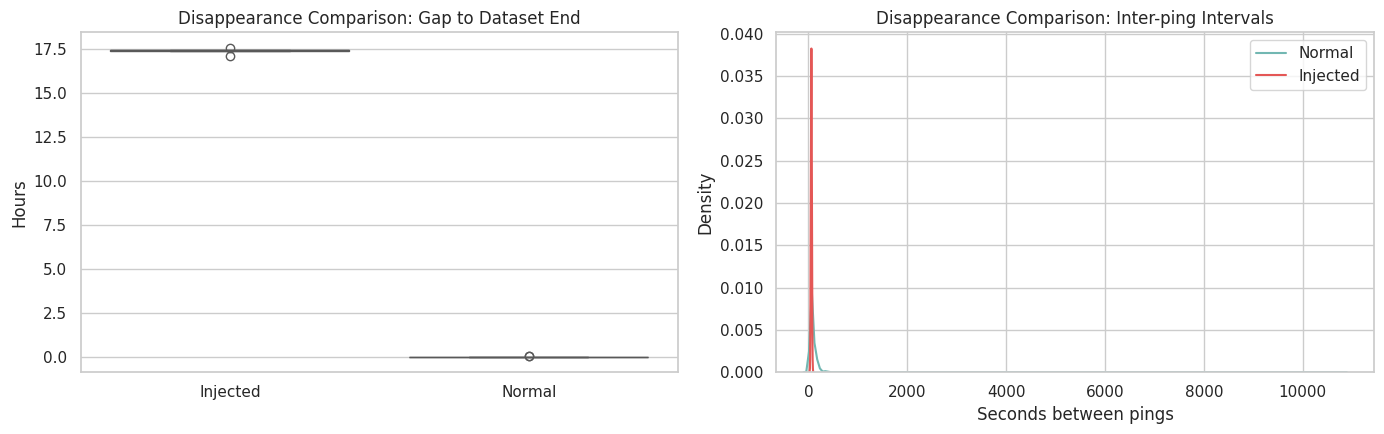

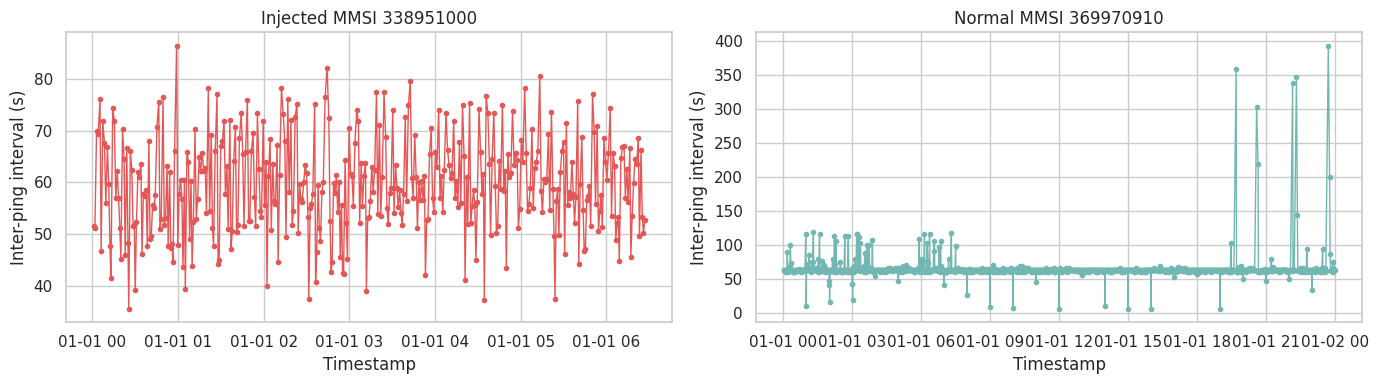

In [8]:
normal_dis_mmsis = sample_normal_mmsis(runs["disappearance"]["db_path"], dis_mmsis, sample_size=12, min_points=120)
normal_dis = load_positions(runs["disappearance"]["db_path"], normal_dis_mmsis)
normal_dis = normal_dis.sort_values(["mmsi", "base_datetime"]).copy()
normal_dis["dt_seconds"] = normal_dis.groupby("mmsi")["base_datetime"].diff().dt.total_seconds()

global_max_ts = pd.concat([dis_positions["base_datetime"], normal_dis["base_datetime"]], ignore_index=True).max()

dis_last = dis_positions.groupby("mmsi")["base_datetime"].max().rename("last_ts").reset_index()
dis_last["group"] = "Injected"

norm_last = normal_dis.groupby("mmsi")["base_datetime"].max().rename("last_ts").reset_index()
norm_last["group"] = "Normal"

last_compare = pd.concat([dis_last, norm_last], ignore_index=True)
last_compare["gap_to_global_end_hours"] = (global_max_ts - last_compare["last_ts"]).dt.total_seconds() / 3600.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(
    data=last_compare,
    x="group",
    y="gap_to_global_end_hours",
    hue="group",
    palette={"Injected": "#e45756", "Normal": "#72b7b2"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Disappearance Comparison: Gap to Dataset End")
axes[0].set_xlabel("")
axes[0].set_ylabel("Hours")

sns.kdeplot(normal_dis["dt_seconds"].dropna(), ax=axes[1], label="Normal", color="#72b7b2")
sns.kdeplot(dis_positions["dt_seconds"].dropna(), ax=axes[1], label="Injected", color="#e45756", warn_singular=False)
axes[1].set_title("Disappearance Comparison: Inter-ping Intervals")
axes[1].set_xlabel("Seconds between pings")
axes[1].legend()

plt.tight_layout()
plt.show()

# Example ship-level comparison
sample_dis_injected = int(dis_check.iloc[0]["mmsi"])
sample_dis_normal = int(normal_dis_mmsis[0]) if normal_dis_mmsis else None

if sample_dis_normal is not None:
    ex_inj = dis_positions[dis_positions["mmsi"] == sample_dis_injected].copy()
    ex_norm = normal_dis[normal_dis["mmsi"] == sample_dis_normal].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(ex_inj["base_datetime"], ex_inj["dt_seconds"], marker=".", linewidth=1, color="#e45756")
    axes[0].set_title(f"Injected MMSI {sample_dis_injected}")
    axes[0].set_xlabel("Timestamp")
    axes[0].set_ylabel("Inter-ping interval (s)")

    axes[1].plot(ex_norm["base_datetime"], ex_norm["dt_seconds"], marker=".", linewidth=1, color="#72b7b2")
    axes[1].set_title(f"Normal MMSI {sample_dis_normal}")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Inter-ping interval (s)")

    plt.tight_layout()
    plt.show()

## Speeding Validation

Goal: show abrupt high-speed spikes stand out from normal speeds for injected ships.

In [9]:
spd_manifest = runs["speeding"]["manifest"]
spd_anoms = pd.DataFrame(spd_manifest.get("anomalies", []))
spd_mmsis = spd_anoms["mmsi"].astype(int).tolist()

spd_positions = load_positions(runs["speeding"]["db_path"], spd_mmsis)
spd_positions = spd_positions.sort_values(["mmsi", "base_datetime"]).copy()
spd_positions["point_index"] = spd_positions.groupby("mmsi").cumcount()

spike_rows = []
for _, row in spd_anoms.iterrows():
    mmsi = int(row["mmsi"])
    for idx in row.get("spike_indices", []):
        spike_rows.append({"mmsi": mmsi, "point_index": int(idx), "is_spike": True})

spike_df = pd.DataFrame(spike_rows)
if spike_df.empty:
    spd_positions["is_spike"] = False
else:
    spd_positions = spd_positions.merge(spike_df, on=["mmsi", "point_index"], how="left")
    spd_positions["is_spike"] = spd_positions["is_spike"].fillna(False)

spd_summary = (
    spd_positions.groupby("mmsi")
    .agg(
        max_sog=("sog", "max"),
        p95_sog=("sog", lambda s: np.percentile(s, 95)),
        mean_sog=("sog", "mean"),
    )
    .reset_index()
    .merge(spd_anoms[["mmsi", "vessel_name"]], on="mmsi", how="left")
)

spd_summary.sort_values("max_sog", ascending=False).head(10)

,mmsi,max_sog,p95_sog,mean_sog,vessel_name
0,338951000,13.088292,12.452215,11.996228,USS LAKE CHAMPLAIN
1,368869000,12.915291,12.545059,11.994535,USS O'KANE
4,369970719,12.902108,12.533425,12.023587,USS ARLINGTON
2,369970707,12.834049,12.508428,12.011505,USS MILWAUKEE
3,369970709,12.830743,12.476002,11.991278,USS LITTLE ROCK


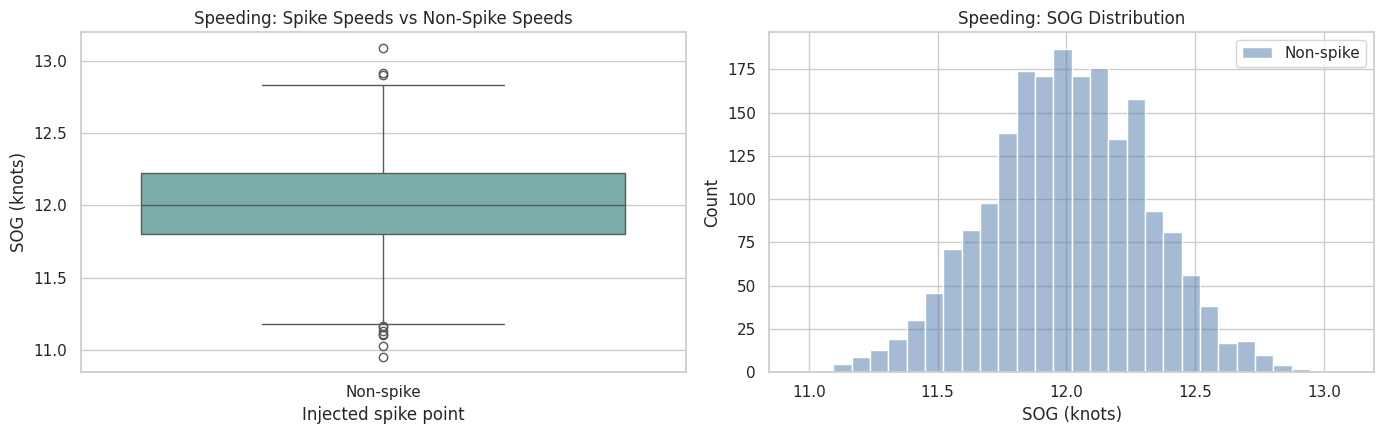

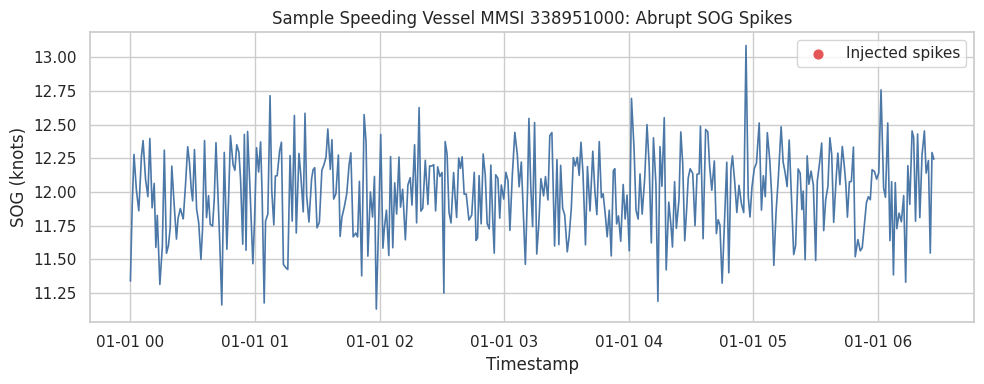

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

spd_plot = spd_positions.copy()
spd_plot["is_spike_bool"] = spd_plot["is_spike"].astype(str).str.lower().eq("true")
spd_plot["is_spike_label"] = np.where(spd_plot["is_spike_bool"], "Spike", "Non-spike")

sns.boxplot(
    data=spd_plot,
    x="is_spike_label",
    y="sog",
    ax=axes[0],
    hue="is_spike_label",
    palette={"Non-spike": "#72b7b2", "Spike": "#e45756"},
    legend=False,
)
axes[0].set_title("Speeding: Spike Speeds vs Non-Spike Speeds")
axes[0].set_xlabel("Injected spike point")
axes[0].set_ylabel("SOG (knots)")

spike_sog = spd_plot.loc[spd_plot["is_spike_bool"] == True, "sog"]
non_spike_sog = spd_plot.loc[spd_plot["is_spike_bool"] == False, "sog"]

sns.histplot(spike_sog, bins=20, ax=axes[1], color="#e45756", alpha=0.8, label="Spike")
sns.histplot(non_spike_sog, bins=30, ax=axes[1], color="#4c78a8", alpha=0.5, label="Non-spike")
axes[1].set_title("Speeding: SOG Distribution")
axes[1].set_xlabel("SOG (knots)")
axes[1].legend()

plt.tight_layout()
plt.show()

sample_spd_mmsi = int(spd_summary.sort_values("max_sog", ascending=False).iloc[0]["mmsi"])
sample_spd = spd_positions[spd_positions["mmsi"] == sample_spd_mmsi].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample_spd["base_datetime"], sample_spd["sog"], color="#4c78a8", linewidth=1.2)
ax.scatter(
    sample_spd.loc[sample_spd["is_spike"].astype(str).str.lower().eq("true"), "base_datetime"],
    sample_spd.loc[sample_spd["is_spike"].astype(str).str.lower().eq("true"), "sog"],
    color="#e45756",
    s=40,
    label="Injected spikes",
)
ax.set_title(f"Sample Speeding Vessel MMSI {sample_spd_mmsi}: Abrupt SOG Spikes")
ax.set_xlabel("Timestamp")
ax.set_ylabel("SOG (knots)")
ax.legend()
plt.tight_layout()
plt.show()

### Injected vs Normal (Speeding)

Compare speed profiles from injected ships against non-injected ships in the same database.

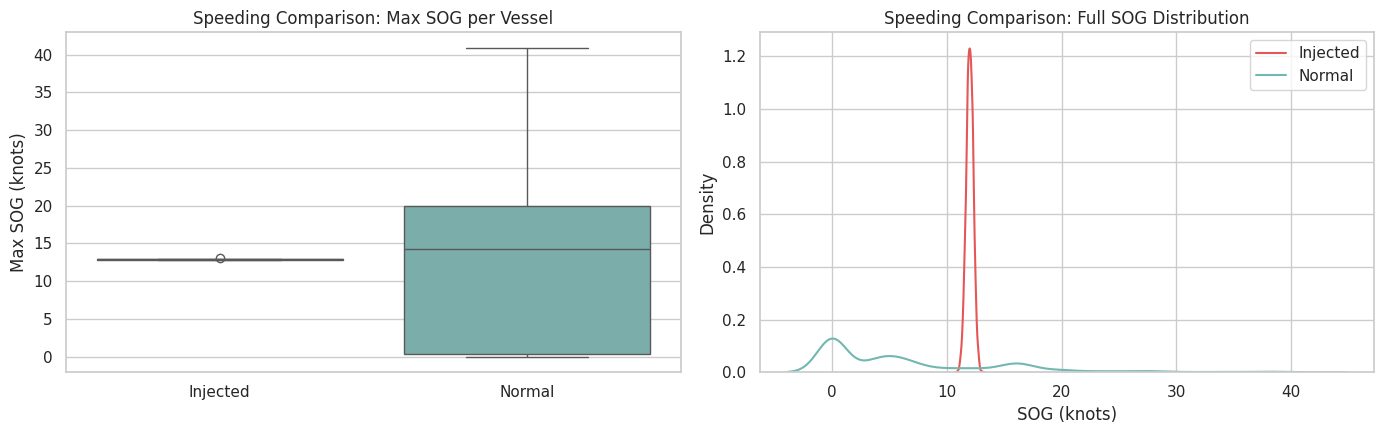

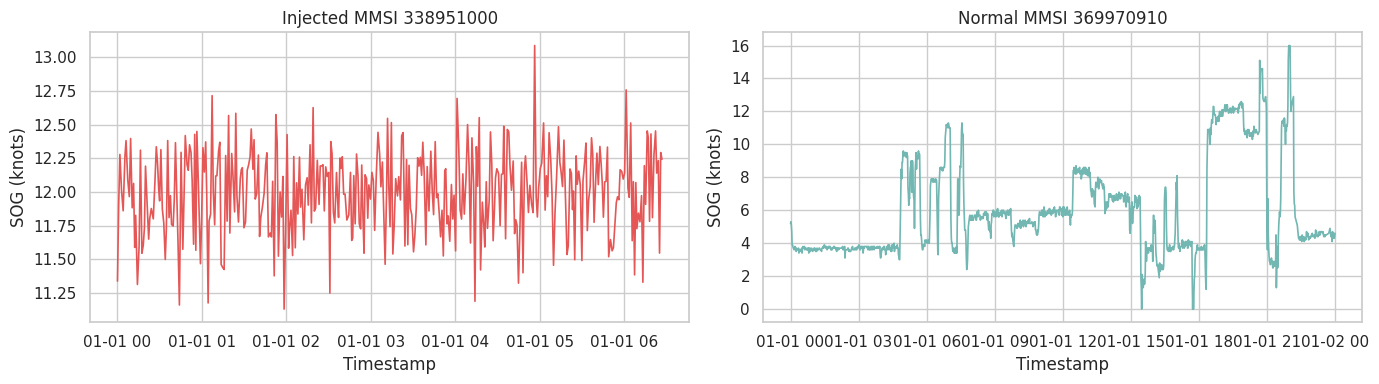

In [11]:
normal_spd_mmsis = sample_normal_mmsis(runs["speeding"]["db_path"], spd_mmsis, sample_size=12, min_points=120)
normal_spd = load_positions(runs["speeding"]["db_path"], normal_spd_mmsis)

inj_speed_stats = spd_positions.groupby("mmsi").agg(max_sog=("sog", "max")).reset_index()
inj_speed_stats["group"] = "Injected"

norm_speed_stats = normal_spd.groupby("mmsi").agg(max_sog=("sog", "max")).reset_index()
norm_speed_stats["group"] = "Normal"

spd_compare = pd.concat([inj_speed_stats, norm_speed_stats], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(
    data=spd_compare,
    x="group",
    y="max_sog",
    hue="group",
    palette={"Injected": "#e45756", "Normal": "#72b7b2"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Speeding Comparison: Max SOG per Vessel")
axes[0].set_xlabel("")
axes[0].set_ylabel("Max SOG (knots)")

sns.kdeplot(spd_positions["sog"], ax=axes[1], label="Injected", color="#e45756")
sns.kdeplot(normal_spd["sog"], ax=axes[1], label="Normal", color="#72b7b2")
axes[1].set_title("Speeding Comparison: Full SOG Distribution")
axes[1].set_xlabel("SOG (knots)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Example ship-level comparison
sample_spd_injected = int(spd_summary.sort_values("max_sog", ascending=False).iloc[0]["mmsi"])
sample_spd_normal = int(normal_spd_mmsis[0]) if normal_spd_mmsis else None

if sample_spd_normal is not None:
    ex_inj = spd_positions[spd_positions["mmsi"] == sample_spd_injected].copy()
    ex_norm = normal_spd[normal_spd["mmsi"] == sample_spd_normal].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(ex_inj["base_datetime"], ex_inj["sog"], color="#e45756", linewidth=1.2)
    axes[0].set_title(f"Injected MMSI {sample_spd_injected}")
    axes[0].set_xlabel("Timestamp")
    axes[0].set_ylabel("SOG (knots)")

    axes[1].plot(ex_norm["base_datetime"], ex_norm["sog"], color="#72b7b2", linewidth=1.2)
    axes[1].set_title(f"Normal MMSI {sample_spd_normal}")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("SOG (knots)")

    plt.tight_layout()
    plt.show()

## Loitering Validation

Goal: show injected ships remained geographically constrained and slow, consistent with loitering behavior.

In [12]:
loit_manifest = runs["loitering"]["manifest"]
loit_anoms = pd.DataFrame(loit_manifest.get("anomalies", []))
loit_mmsis = loit_anoms["mmsi"].astype(int).tolist()

loit_positions = load_positions(runs["loitering"]["db_path"], loit_mmsis)
loit_positions = loit_positions.merge(
    loit_anoms[["mmsi", "center_lat", "center_lon", "radius_nm", "vessel_name"]],
    on="mmsi",
    how="left",
)

loit_positions["dist_nm_from_center"] = to_nm_distance(
    loit_positions["lat"],
    loit_positions["lon"],
    loit_positions["center_lat"],
    loit_positions["center_lon"],
)
loit_positions["within_radius"] = loit_positions["dist_nm_from_center"] <= loit_positions["radius_nm"]

loit_summary = (
    loit_positions.groupby("mmsi")
    .agg(
        mean_sog=("sog", "mean"),
        max_sog=("sog", "max"),
        mean_dist_nm=("dist_nm_from_center", "mean"),
        p95_dist_nm=("dist_nm_from_center", lambda s: np.percentile(s, 95)),
        pct_within_radius=("within_radius", "mean"),
    )
    .reset_index()
    .merge(loit_anoms[["mmsi", "vessel_name", "radius_nm"]], on="mmsi", how="left")
)

loit_summary["pct_within_radius"] = loit_summary["pct_within_radius"] * 100
loit_summary.sort_values("pct_within_radius", ascending=False).head(10)

,mmsi,mean_sog,max_sog,mean_dist_nm,p95_dist_nm,pct_within_radius,vessel_name,radius_nm
0,338812000,0.388320,0.798795,0.196902,0.376736,100.0,USS LASSEN,0.4
1,338839000,0.395277,0.799925,0.202872,0.378484,100.0,USS FITZGERALD,0.4
2,366984000,0.392055,0.799337,0.204220,0.373089,100.0,USS THEODORE ROOSEVE,0.4
3,368988000,0.386200,0.796376,0.206857,0.376947,100.0,USS VICKSBURG,0.4
4,369970968,0.390316,0.796311,0.201734,0.384303,100.0,USS SIOUX CITY,0.4


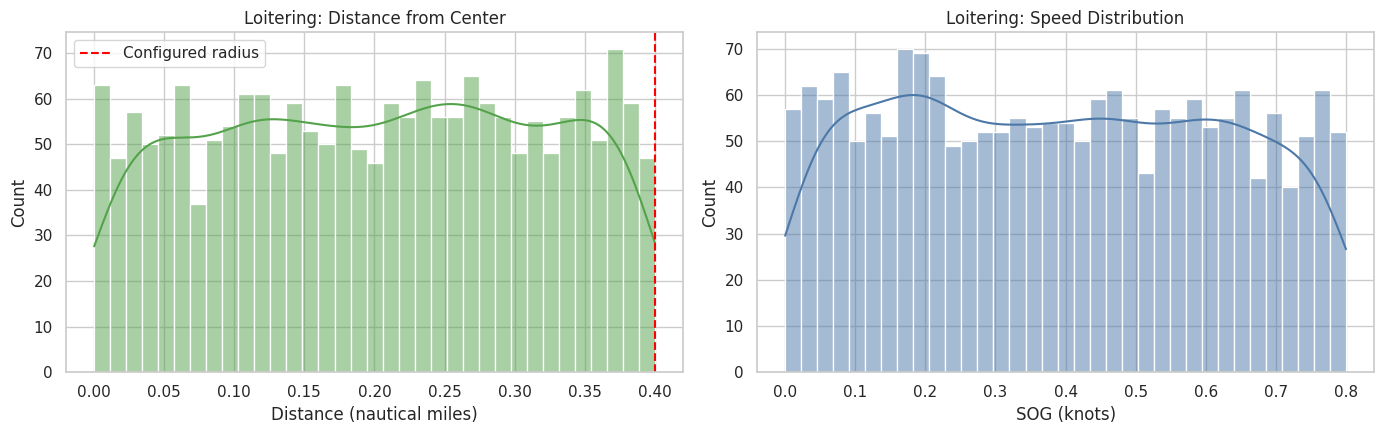

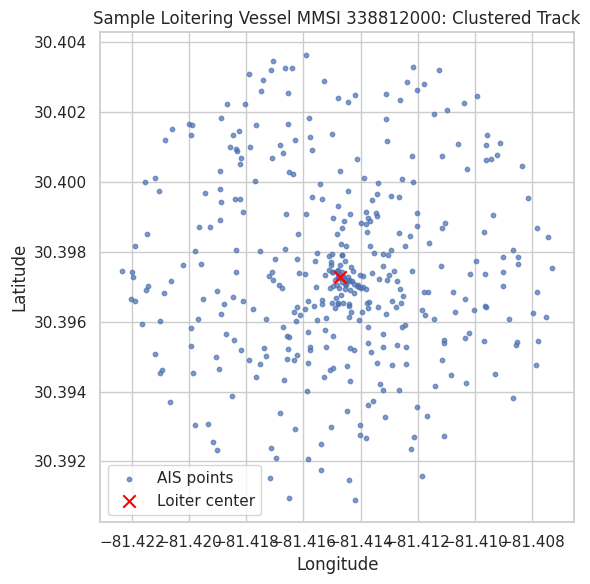

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(loit_positions["dist_nm_from_center"], bins=35, kde=True, ax=axes[0], color="#54a24b")
axes[0].axvline(loit_anoms["radius_nm"].median(), color="red", linestyle="--", label="Configured radius")
axes[0].set_title("Loitering: Distance from Center")
axes[0].set_xlabel("Distance (nautical miles)")
axes[0].legend()

sns.histplot(loit_positions["sog"], bins=35, kde=True, ax=axes[1], color="#4c78a8")
axes[1].set_title("Loitering: Speed Distribution")
axes[1].set_xlabel("SOG (knots)")

plt.tight_layout()
plt.show()

sample_loit_mmsi = int(loit_summary.sort_values("mean_dist_nm").iloc[0]["mmsi"])
sample_loit = loit_positions[loit_positions["mmsi"] == sample_loit_mmsi].copy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample_loit["lon"], sample_loit["lat"], s=10, alpha=0.7, label="AIS points")
ax.scatter(
    [sample_loit["center_lon"].iloc[0]],
    [sample_loit["center_lat"].iloc[0]],
    color="red",
    s=80,
    marker="x",
    label="Loiter center",
)
ax.set_title(f"Sample Loitering Vessel MMSI {sample_loit_mmsi}: Clustered Track")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()

### Injected vs Normal (Loitering)

Compare spatial spread and speed between injected loitering ships and non-injected ships.

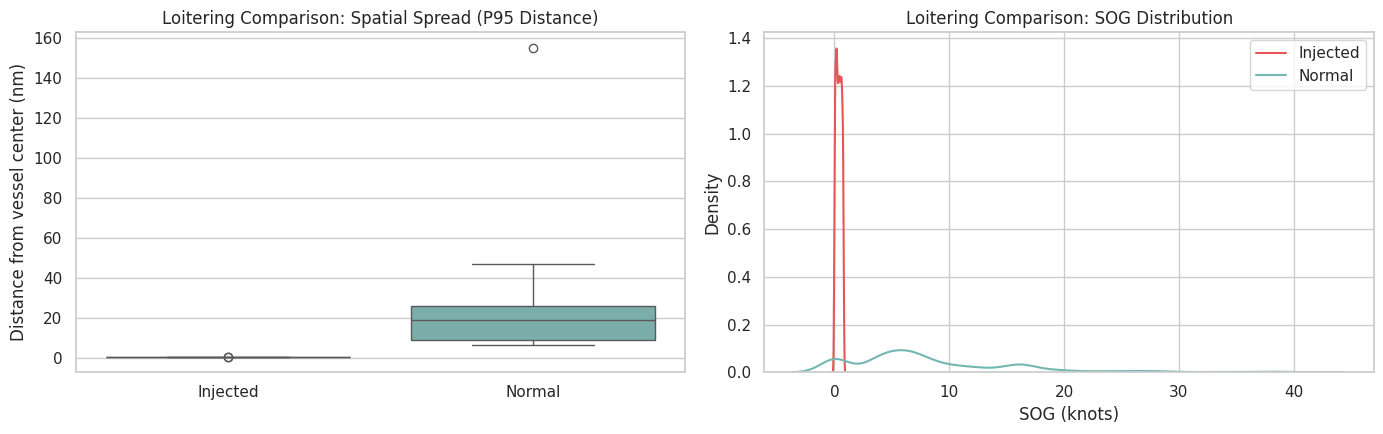

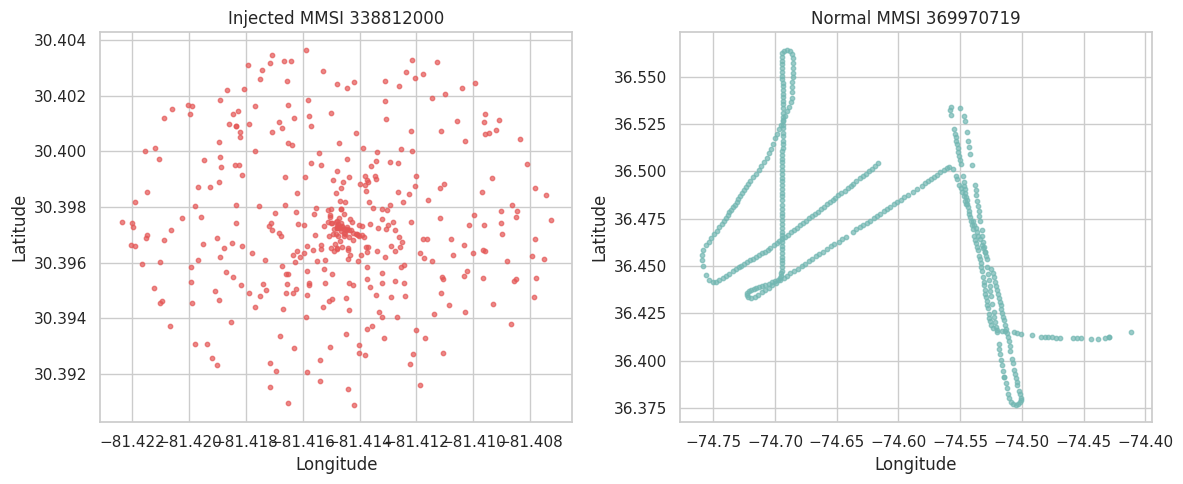

In [14]:
normal_loit_mmsis = sample_normal_mmsis(runs["loitering"]["db_path"], loit_mmsis, sample_size=12, min_points=120)
normal_loit = load_positions(runs["loitering"]["db_path"], normal_loit_mmsis)

normal_centroids = (
    normal_loit.groupby("mmsi")
    .agg(center_lat=("lat", "mean"), center_lon=("lon", "mean"))
    .reset_index()
)
normal_loit = normal_loit.merge(normal_centroids, on="mmsi", how="left")
normal_loit["dist_nm_from_center"] = to_nm_distance(
    normal_loit["lat"], normal_loit["lon"], normal_loit["center_lat"], normal_loit["center_lon"]
)

inj_spread = loit_positions.groupby("mmsi").agg(p95_dist_nm=("dist_nm_from_center", lambda s: np.percentile(s, 95))).reset_index()
inj_spread["group"] = "Injected"
norm_spread = normal_loit.groupby("mmsi").agg(p95_dist_nm=("dist_nm_from_center", lambda s: np.percentile(s, 95))).reset_index()
norm_spread["group"] = "Normal"
spread_compare = pd.concat([inj_spread, norm_spread], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(
    data=spread_compare,
    x="group",
    y="p95_dist_nm",
    hue="group",
    palette={"Injected": "#e45756", "Normal": "#72b7b2"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Loitering Comparison: Spatial Spread (P95 Distance)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Distance from vessel center (nm)")

sns.kdeplot(loit_positions["sog"], ax=axes[1], label="Injected", color="#e45756")
sns.kdeplot(normal_loit["sog"], ax=axes[1], label="Normal", color="#72b7b2")
axes[1].set_title("Loitering Comparison: SOG Distribution")
axes[1].set_xlabel("SOG (knots)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Example ship-level track comparison
sample_loit_injected = int(loit_summary.sort_values("mean_dist_nm").iloc[0]["mmsi"])
sample_loit_normal = int(normal_loit_mmsis[0]) if normal_loit_mmsis else None

if sample_loit_normal is not None:
    ex_inj = loit_positions[loit_positions["mmsi"] == sample_loit_injected].copy()
    ex_norm = normal_loit[normal_loit["mmsi"] == sample_loit_normal].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(ex_inj["lon"], ex_inj["lat"], s=10, alpha=0.7, color="#e45756")
    axes[0].set_title(f"Injected MMSI {sample_loit_injected}")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    axes[1].scatter(ex_norm["lon"], ex_norm["lat"], s=10, alpha=0.7, color="#72b7b2")
    axes[1].set_title(f"Normal MMSI {sample_loit_normal}")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()

## Injection Success Checklist

These checks summarize whether generated tracks exhibit the intended anomaly signatures.

In [15]:
dis_pass = (dis_check["cv_interval"].fillna(1e9) < 0.2).mean() * 100
spd_pass = (spd_summary["max_sog"] > spd_summary["p95_sog"] + 10).mean() * 100
loit_pass = (loit_summary["pct_within_radius"] >= 90).mean() * 100

checklist = pd.DataFrame(
    [
        {
            "scenario": "disappearance",
            "criterion": "Low interval variability (CV < 0.2) before stop",
            "pass_rate_percent": round(dis_pass, 1),
        },
        {
            "scenario": "speeding",
            "criterion": "Clear speed spikes (max > p95 + 10 knots)",
            "pass_rate_percent": round(spd_pass, 1),
        },
        {
            "scenario": "loitering",
            "criterion": "Most points remain inside configured radius (>=90%)",
            "pass_rate_percent": round(loit_pass, 1),
        },
    ]
)

checklist

,scenario,criterion,pass_rate_percent
0,disappearance,Low interval variability (CV < 0.2) before stop,100.0
1,speeding,Clear speed spikes (max > p95 + 10 knots),0.0
2,loitering,Most points remain inside configured radius (>...,100.0
